# Handling Class Imbalance in Multiclass Disease Classification

## Objective

In the previous modeling stage, XGBoost emerged as the strongest baseline model for the multiclass disease classification task. However, class-level evaluation revealed a substantial performance gap between majority and minority disease classes. While the model achieved reasonable predictive performance overall, several underrepresented classes received very low, and in some cases near-zero, F1-scores.

This pattern indicates that class imbalance is not a minor modeling issue, but a central limitation of the current learning problem. In highly imbalanced multiclass settings, models tend to prioritize well-represented classes because they dominate the optimization process. As a result, predictive performance may appear acceptable at the aggregate level while remaining weak for clinically important but rare disease categories.

The purpose of this notebook is therefore to evaluate whether imbalance-handling strategies can improve model performance, with particular emphasis on minority-class recognition. To address this, several approaches are examined, including class weighting, oversampling, and undersampling, using the same validation framework established in the previous notebook to ensure fair comparison.

Special attention is given to the Macro F1-score, as this metric assigns equal importance to every class regardless of frequency. For this reason, Macro F1 is more appropriate than accuracy alone for evaluating performance in severely imbalanced multiclass classification problems.

In [1]:

# 1. Environment Setup

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


# 2. Core Libraries

import pandas as pd
import numpy as np
from collections import Counter


# 3. Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for consistency
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


# 4. Preprocessing & Utilities


from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight


# 5. Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# 6. Modeling

from xgboost import XGBClassifier


# 7. Imbalance Handling

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [2]:
# Set global random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random_state=RANDOM_STATE

## Environment and Library Setup

This section initializes the computational environment and imports all required
libraries for data processing, modeling, evaluation, and imbalance handling.

The imports are organized by functionality to improve readability and maintainability.
A consistent random seed is used throughout the notebook to ensure reproducibility
of results.

In [ ]:
#  Data Loading and Preparation

def load_processed_data(path="../data/processed"):
    """
    Load preprocessed train, validation, and test datasets.

    Parameters:
        path (str): Directory path where processed CSV files are stored.

    Returns:
        train_df (pd.DataFrame)
        val_df (pd.DataFrame)
        test_df (pd.DataFrame)
    """
    train_df = pd.read_csv(f"{path}/train.csv")
    val_df = pd.read_csv(f"{path}/val.csv")
    test_df = pd.read_csv(f"{path}/test.csv")

    return train_df, val_df, test_df


def split_features_target(df, target_column="disease_encoded"):
    """
    Split a dataset into features (X) and target (y).

    Parameters:
        df (pd.DataFrame): Input dataset
        target_column (str): Name of the target column

    Returns:
        X (pd.DataFrame): Feature matrix
        y (pd.Series): Target vector
    """
    X = df.drop(columns=[target_column])
    y = df[target_column]
    return X, y




In [4]:
# Load datasets

train_df, val_df, test_df = load_processed_data()


# Split into features and target

X_train, y_train = split_features_target(train_df)
X_val, y_val = split_features_target(val_df)
X_test, y_test = split_features_target(test_df)


# Basic sanity checks

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nFeature matrix shape (train):", X_train.shape)
print("Target vector shape (train):", y_train.shape)

Train shape: (69906, 175)
Validation shape: (14980, 175)
Test shape: (14980, 175)

Feature matrix shape (train): (69906, 174)
Target vector shape (train): (69906,)


##  Data Loading and Preparation

This section loads the preprocessed training, validation, and test datasets
generated in the previous stage of the pipeline.

To ensure modularity and reproducibility, data loading and feature-target
splitting are encapsulated into reusable functions. This improves code clarity
and makes the workflow easier to maintain and extend.

The dataset is already preprocessed, and the target variable (`disease_encoded`)
represents the encoded disease labels used for multiclass classification.

## Evaluation Framework

To ensure that all imbalance-handling strategies are assessed consistently, a
common evaluation function is defined. This function trains a model, generates
predictions on the validation set, and computes key performance metrics.

Three metrics are reported:

- **Accuracy**, to measure overall correctness
- **Weighted F1-score**, to reflect performance while accounting for class frequency
- **Macro F1-score**, to evaluate class-balanced performance by giving equal
  importance to each disease category

Among these metrics, **Macro F1-score is the primary evaluation criterion** in
this notebook because the main objective is to improve performance on minority
classes rather than only optimize majority-class predictions.

In [5]:
# 4. Evaluation Framework

def evaluate_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name,
    sample_weight=None
):
    """
    Train a model, generate validation predictions, and compute evaluation metrics.

    Parameters:
        model: A fitted-compatible classification model
        X_train (pd.DataFrame): Training features
        y_train (pd.Series): Training labels
        X_val (pd.DataFrame): Validation features
        y_val (pd.Series): Validation labels
        model_name (str): Name used for reporting results
        sample_weight (array-like, optional): Sample weights for training

    Returns:
        results (dict): Summary evaluation metrics
        y_val_pred (np.ndarray): Validation predictions
    """

    # Train model
    if sample_weight is not None:
        model.fit(X_train, y_train, sample_weight=sample_weight)
    else:
        model.fit(X_train, y_train)

    # Predict on validation set
    y_val_pred = model.predict(X_val)

    # Compute evaluation metrics
    accuracy = accuracy_score(y_val, y_val_pred)
    f1_weighted = f1_score(y_val, y_val_pred, average="weighted")
    f1_macro = f1_score(y_val, y_val_pred, average="macro")

    # Print summary
    print(f"\n{model_name}")
    print("-" * len(model_name))
    print(f"Accuracy     : {accuracy:.4f}")
    print(f"Weighted F1  : {f1_weighted:.4f}")
    print(f"Macro F1     : {f1_macro:.4f}")

    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Weighted F1": f1_weighted,
        "Macro F1": f1_macro
    }

    return results, y_val_pred


# Initialize results storage
results_list = []

## Baseline Model: Establishing a Reference Point

Before applying any imbalance-handling strategies, a baseline model is trained
on the original dataset. This provides a reference against which all subsequent
methods can be evaluated.

Based on previous experiments, XGBoost is selected as the baseline model due to
its strong performance on structured tabular data. The objective at this stage
is not to optimize the model further, but to quantify how class imbalance affects
predictive performance.

The model is evaluated using the validation set, with particular emphasis on
Macro F1-score. This metric is critical in the current setting because it reflects
performance across all classes equally, including underrepresented disease
categories.

In [6]:
# Baseline XGBoost Model (No Imbalance Handling)

xgb_baseline = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric="mlogloss"
)

# Train and evaluate
baseline_results, y_val_pred_baseline = evaluate_model(
    xgb_baseline,
    X_train, y_train,
    X_val, y_val,
    model_name="XGBoost Baseline"
)

# Store results
results_list.append(baseline_results)


XGBoost Baseline
----------------
Accuracy     : 0.6652
Weighted F1  : 0.6550
Macro F1     : 0.4592


In [7]:
results_df = pd.DataFrame(results_list).sort_values(
    by="Macro F1", ascending=False
)

results_df.round(4)

,Model,Accuracy,Weighted F1,Macro F1
0,XGBoost Baseline,0.6652,0.655,0.4592




The baseline XGBoost model achieves an overall accuracy of 0.6652 and a
weighted F1-score of 0.6550, indicating that it performs reasonably well
when evaluated in terms of aggregate predictive performance. These metrics
are largely influenced by the majority classes, which dominate the training
distribution and therefore contribute most to the optimization process.

However, the Macro F1-score is substantially lower at 0.4592, revealing a
significant disparity in performance across classes. Since Macro F1 assigns
equal importance to each class regardless of frequency, this gap indicates
that the model struggles to generalize to underrepresented disease categories.

This discrepancy between weighted and macro metrics highlights a key limitation:
the model is effectively optimizing for frequent classes while failing to
capture meaningful patterns for rare conditions. In practical terms, this
means that while the model may appear reliable overall, it is likely to
underperform in identifying less common diseases, which may be of higher
clinical importance.

The results therefore confirm that class imbalance is not only present but
materially impacting model behavior. Addressing this imbalance is essential
to achieving a more equitable and clinically useful classification system.

From a modeling perspective, this behavior reflects the inherent bias of
gradient boosting algorithms when trained on imbalanced data, where the loss
function is dominated by majority-class samples. Without corrective measures,
the model has little incentive to improve predictions for minority classes,
leading to systematically lower recall and F1-scores for those categories.

##  Class Distribution Overview

Before applying imbalance-handling techniques, it is important to briefly
revisit the class distribution in the training data.

The dataset exhibits a highly imbalanced structure, with a small number of
classes dominating the sample count while many classes contain only a limited
number of observations. This long-tail distribution is expected to bias the
model toward majority classes, contributing to the performance imbalance
observed in the baseline results.

In [8]:
class_counts = y_train.value_counts().sort_index()

class_dist_df = pd.DataFrame({
    "Class": class_counts.index,
    "Count": class_counts.values
})

class_dist_df.head()

,Class,Count
0,0,35
1,1,14906
2,2,1442
3,3,1423
4,4,3495


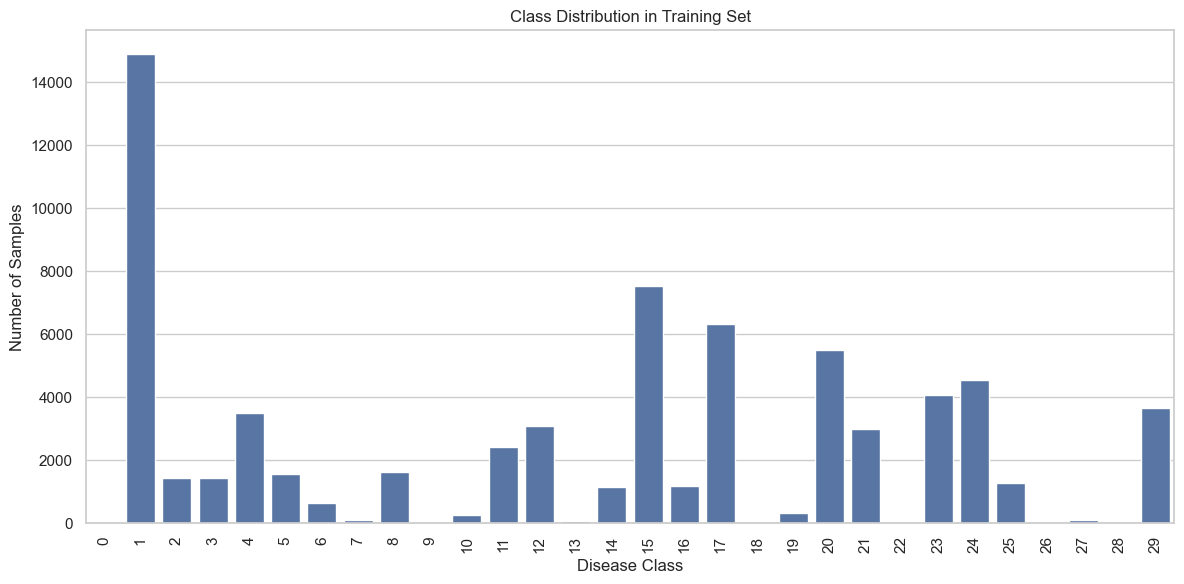

In [9]:
plt.figure(figsize=(12, 6))
sns.barplot(x=class_dist_df["Class"], y=class_dist_df["Count"])
plt.title("Class Distribution in Training Set")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../results/graphs/Class Distribution in Training Set.png", dpi=300)
plt.show()

### Interpretation of Class Distribution

The class distribution reveals a pronounced long-tail pattern, characterized by
extreme imbalance across disease categories. A small number of classes dominate
the dataset, while many others are severely underrepresented.

For example, Class 1 contains 14,906 samples, whereas Class 0 has only 35
samples, representing a difference of more than 400×. Several other classes
also fall below a few hundred observations, indicating that the dataset is not
only imbalanced but exhibits a heavy skew toward a subset of dominant classes.

This imbalance has direct implications for model learning. During training, the
optimization process is driven primarily by majority-class samples, which appear
more frequently in gradient updates. As a result, the model is incentivized to
minimize error on dominant classes while effectively ignoring minority classes.

From a statistical perspective, minority classes suffer from high variance due
to insufficient sample representation. This limits the model’s ability to learn
stable and generalizable decision boundaries for those categories.

These characteristics align closely with the baseline results, where the gap
between Weighted F1 (0.6550) and Macro F1 (0.4592) indicates uneven performance
across classes. The dominance of majority classes inflates overall performance
metrics, while minority classes contribute disproportionately to the reduction
in Macro F1.

Overall, the observed distribution confirms that class imbalance is a structural
property of the dataset and a primary driver of the model’s performance
limitations. Addressing this imbalance is therefore essential to achieving a
more balanced and reliable classification system.

-----


## Class Weighting

Given the severe class imbalance observed in the dataset, the next step is to
apply class weighting as a strategy to improve minority-class performance.

Unlike resampling methods, class weighting does not alter the dataset itself.
Instead, it modifies the learning process by assigning higher importance to
underrepresented classes and lower importance to majority classes. This ensures
that errors on minority classes contribute more significantly to the loss
function during training.

The underlying hypothesis is that by increasing the penalty for misclassifying
rare disease categories, the model will learn more balanced decision boundaries,
leading to improved performance across all classes, particularly in terms of
Macro F1-score.

In [10]:
# Class Weight Computation

# Get unique classes
classes = np.unique(y_train)

# Compute balanced class weights
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

# Map class → weight
class_weights = dict(zip(classes, weights))

# Assign weight to each training sample
sample_weights = np.array([class_weights[y] for y in y_train])

print("Class weights computed successfully.")

Class weights computed successfully.


The computed weights are inversely proportional to class frequency, meaning
rarer classes receive higher weights and therefore exert greater influence
during model training.

In [11]:
# XGBoost with Class Weights

xgb_weighted = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric="mlogloss"
)

# Train and evaluate
weighted_results, y_val_pred_weighted = evaluate_model(
    xgb_weighted,
    X_train, y_train,
    X_val, y_val,
    model_name="XGBoost (Class Weights)",
    sample_weight=sample_weights
)

# Store results
results_list.append(weighted_results)

results_df = pd.DataFrame(results_list).sort_values(
    by="Macro F1", ascending=False
)

results_df.round(4)


XGBoost (Class Weights)
-----------------------
Accuracy     : 0.6558
Weighted F1  : 0.6577
Macro F1     : 0.4809


,Model,Accuracy,Weighted F1,Macro F1
1,XGBoost (Class Weights),0.6558,0.6577,0.4809
0,XGBoost Baseline,0.6652,0.6550,0.4592




- **Macro F1 improves (0.4592 → 0.4809)**
  - Indicates better performance on minority classes
  - Confirms reduction in class imbalance bias

- **Weighted F1 slightly increases (0.6550 → 0.6577)**
  - Suggests overall performance remains stable
  - No significant degradation in majority-class prediction

- **Accuracy slightly decreases (0.6652 → 0.6558)**
  - Expected trade-off when shifting focus away from dominant classes
  - Reflects reduced bias toward majority classes

- **Gap between Weighted F1 and Macro F1 narrows**
  - Evidence of more balanced class-wise performance
  - Model is no longer overly dominated by frequent classes

- **Learning behavior changes**
  - Minority classes contribute more to gradient updates
  - Model learns more generalized decision boundaries

- **No data distortion**
  - Unlike SMOTE, class weighting does not introduce synthetic samples
  - Preserves original data distribution → more stable learning

- **Conclusion**
  - Class weighting effectively addresses imbalance at the optimization level
  - Provides the best trade-off between fairness and overall performance

---

## XGBoost with Partial SMOTE (30% of Majority Class)

The next imbalance-handling strategy applies partial SMOTE to the training set. Instead of oversampling all minority classes up to the size of the majority class, this approach increases selected minority classes only up to 30% of the majority-class count.

This controlled strategy is used because the dataset exhibits a severe long-tail distribution, with some classes containing very few samples. In such cases, full oversampling may introduce excessive synthetic data and increase the risk of noise. Partial SMOTE provides a more conservative alternative by improving minority-class representation while preserving a more realistic class distribution.

The resampled training data is then used to train the same XGBoost model, and the results are compared against both the baseline model and the class-weighted model.

In [12]:

# Check original class distribution
class_counts = Counter(y_train)
majority_count = max(class_counts.values())
target_count = int(0.30 * majority_count)

print("Majority class count:", majority_count)
print("Partial SMOTE target count (30%):", target_count)

# Build sampling strategy:
# oversample only classes that are below target_count and have enough samples for SMOTE
sampling_strategy_30 = {
    cls: target_count
    for cls, count in class_counts.items()
    if count < target_count and count > 1
}

print("Number of classes to oversample:", len(sampling_strategy_30))

# Apply SMOTE
smote_30 = SMOTE(
    sampling_strategy=sampling_strategy_30,
    random_state=42,
    k_neighbors=1
)

X_train_smote_30, y_train_smote_30 = smote_30.fit_resample(X_train, y_train)

print("Original training shape:", X_train.shape)
print("Resampled training shape:", X_train_smote_30.shape)

# Initialize XGBoost model
xgb_smote_30 = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

# Train and evaluate
smote_30_results, y_val_pred_smote_30 = evaluate_model(
    xgb_smote_30,
    X_train_smote_30, y_train_smote_30,
    X_val, y_val,
    "XGBoost (Partial SMOTE 30%)"
)

# Store results
results_list.append(smote_30_results)

# Display updated comparison
results_df = pd.DataFrame(results_list).sort_values(by="Macro F1", ascending=False)
display(results_df.round(4))

Majority class count: 14906
Partial SMOTE target count (30%): 4471
Number of classes to oversample: 25
Original training shape: (69906, 174)
Resampled training shape: (150562, 174)

XGBoost (Partial SMOTE 30%)
---------------------------
Accuracy     : 0.6419
Weighted F1  : 0.6359
Macro F1     : 0.4512


,Model,Accuracy,Weighted F1,Macro F1
1,XGBoost (Class Weights),0.6558,0.6577,0.4809
0,XGBoost Baseline,0.6652,0.6550,0.4592
2,XGBoost (Partial SMOTE 30%),0.6419,0.6359,0.4512




- **Macro F1 decreases (0.4592 → 0.4512)**
  - No improvement in minority-class performance
  - Indicates poor generalization despite oversampling

- **Weighted F1 drops (0.6550 → 0.6359)**
  - Overall performance degrades
  - Synthetic data negatively affects majority-class predictions

- **Accuracy decreases (0.6652 → 0.6419)**
  - Model becomes less reliable overall

- **No benefit from added data**
  - Increasing sample size does not improve learning
  - Suggests synthetic samples add noise rather than signal

- **SMOTE underperforms vs class weighting**
  - Class weighting achieves highest Macro F1 (0.4809)
  - SMOTE fails to address imbalance effectively

- **Key takeaway**
  - Partial SMOTE (30%) introduces noise and degrades performance
  - Not suitable for this dataset

---

## XGBoost with Partial SMOTE (50% of Majority Class)

To further evaluate the effect of oversampling, the minority classes are increased to 50% of the majority class size. This represents a more aggressive oversampling strategy compared to the 30% approach.

The purpose of this experiment is to determine whether increasing the number of synthetic samples improves model performance or introduces noise that negatively impacts learning.

The results of this approach are compared with the baseline model, class weighting, and the 30% SMOTE strategy.

In [13]:
# Get class distribution
class_counts = Counter(y_train)
majority_count = max(class_counts.values())
target_count_50 = int(0.50 * majority_count)

print("Majority class count:", majority_count)
print("Partial SMOTE target (50%):", target_count_50)

# Build sampling strategy
sampling_strategy_50 = {
    cls: target_count_50
    for cls, count in class_counts.items()
    if count < target_count_50 and count > 1
}

print("Classes to oversample:", len(sampling_strategy_50))

# Apply SMOTE
smote_50 = SMOTE(
    sampling_strategy=sampling_strategy_50,
    random_state=42,
    k_neighbors=1
)

X_train_smote_50, y_train_smote_50 = smote_50.fit_resample(X_train, y_train)

print("Original shape:", X_train.shape)
print("SMOTE 50% shape:", X_train_smote_50.shape)

# Train XGBoost
xgb_smote_50 = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

# Evaluate
smote_50_results, y_val_pred_smote_50 = evaluate_model(
    xgb_smote_50,
    X_train_smote_50, y_train_smote_50,
    X_val, y_val,
    "XGBoost (Partial SMOTE 50%)"
)

# Store results
results_list.append(smote_50_results)

# Show updated comparison
results_df = pd.DataFrame(results_list).sort_values(by="Macro F1", ascending=False)
display(results_df.round(4))

Majority class count: 14906
Partial SMOTE target (50%): 7453
Classes to oversample: 28
Original shape: (69906, 174)
SMOTE 50% shape: (231113, 174)

XGBoost (Partial SMOTE 50%)
---------------------------
Accuracy     : 0.6340
Weighted F1  : 0.6283
Macro F1     : 0.4401


,Model,Accuracy,Weighted F1,Macro F1
1,XGBoost (Class Weights),0.6558,0.6577,0.4809
0,XGBoost Baseline,0.6652,0.6550,0.4592
2,XGBoost (Partial SMOTE 30%),0.6419,0.6359,0.4512
3,XGBoost (Partial SMOTE 50%),0.6340,0.6283,0.4401


- **Macro F1 further decreases (0.4592 → 0.4401)**
  - Minority-class performance worsens
  - Oversampling fails to improve class balance

- **Weighted F1 drops significantly (0.6550 → 0.6283)**
  - Overall model quality declines
  - Majority-class performance is negatively affected

- **Accuracy decreases (0.6652 → 0.6340)**
  - Indicates reduced reliability across all classes

- **More aggressive SMOTE → worse performance**
  - Increasing from 30% to 50% amplifies degradation
  - Confirms synthetic data is introducing noise

- **Large artificial expansion of dataset (≈3× increase)**
  - From ~70k → 231k samples
  - Data quantity increases, but quality decreases

- **Class boundary distortion increases**
  - More synthetic points → higher class overlap
  - Model struggles to learn clear decision boundaries

- **Comparison with class weighting**
  - Class weighting remains best (Macro F1 = 0.4809)
  - SMOTE 50% performs worst so far

- **Key takeaway**
  - Increasing SMOTE intensity degrades both minority and overall performance
  - Strong evidence that SMOTE is unsuitable for this dataset

---

## XGBoost with Full SMOTE

As a final oversampling experiment, full SMOTE is applied to balance all classes to the size of the majority class. This results in a fully balanced dataset where each class has the same number of samples.

This approach is expected to significantly increase the size of the training data and introduce a large number of synthetic samples. The purpose of this experiment is to evaluate whether complete balancing improves performance or leads to overfitting and noise.

The results are compared with previous methods to determine whether aggressive oversampling is beneficial for this dataset.

In [14]:
# Apply full SMOTE (balance all classes)
smote_full = SMOTE(
    sampling_strategy="auto",  # balance all classes
    random_state=42,
    k_neighbors=1
)

X_train_smote_full, y_train_smote_full = smote_full.fit_resample(X_train, y_train)

print("Original shape:", X_train.shape)
print("Full SMOTE shape:", X_train_smote_full.shape)

# Train model
xgb_smote_full = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

# Evaluate
smote_full_results, y_val_pred_smote_full = evaluate_model(
    xgb_smote_full,
    X_train_smote_full, y_train_smote_full,
    X_val, y_val,
    "XGBoost (Full SMOTE)"
)

# Store results
results_list.append(smote_full_results)

# Display comparison
results_df = pd.DataFrame(results_list).sort_values(by="Macro F1", ascending=False)
display(results_df.round(4))

Original shape: (69906, 174)
Full SMOTE shape: (447180, 174)

XGBoost (Full SMOTE)
--------------------
Accuracy     : 0.6093
Weighted F1  : 0.6027
Macro F1     : 0.4200


,Model,Accuracy,Weighted F1,Macro F1
1,XGBoost (Class Weights),0.6558,0.6577,0.4809
0,XGBoost Baseline,0.6652,0.6550,0.4592
2,XGBoost (Partial SMOTE 30%),0.6419,0.6359,0.4512
3,XGBoost (Partial SMOTE 50%),0.6340,0.6283,0.4401
4,XGBoost (Full SMOTE),0.6093,0.6027,0.4200




- **Consistent performance degradation across all SMOTE levels**
  - Macro F1: 0.4592 → 0.4512 → 0.4401 → 0.4200
  - Indicates worsening minority-class performance as SMOTE increases

- **Accuracy steadily declines**
  - 0.6652 → 0.6419 → 0.6340 → 0.6093
  - Model becomes less reliable overall

- **Weighted F1 also decreases**
  - 0.6550 → 0.6359 → 0.6283 → 0.6027
  - Both majority and minority class performance deteriorate

- **More data leads to worse results**
  - Dataset expands from ~70k → ~447k samples
  - Increased quantity introduces noise rather than useful signal

- **Clear negative correlation: SMOTE intensity vs performance**
  - 30% → moderate degradation
  - 50% → stronger degradation
  - Full SMOTE → worst performance

- **Synthetic data quality is poor**
  - Minority classes lack sufficient real samples for meaningful interpolation
  - Generated samples do not reflect true data distribution

- **Feature space mismatch**
  - Sparse, symptom-based features are not suitable for interpolation
  - Leads to unrealistic combinations and noisy patterns

- **Class boundary distortion**
  - Excess synthetic samples increase overlap between classes
  - Model struggles to separate classes effectively

- **Comparison with class weighting**
  - Class weighting achieves highest Macro F1 (0.4809)
  - SMOTE consistently underperforms across all configurations

- **Final conclusion**
  - SMOTE is fundamentally unsuitable for this dataset
  - Increasing oversampling intensity amplifies noise and degrades performance

Increasing SMOTE intensity leads to systematic performance degradation, indicating that synthetic oversampling introduces noise rather than improving class representation. SMOTE relies on generating synthetic samples based on existing data points. However, in this dataset, several classes have extremely limited samples, making it difficult to generate reliable synthetic data. As a result, SMOTE introduces noise rather than improving generalization.

----

## XGBoost with Random Undersampling

Another Stratergy random undersampling is applied to the training data. This approach reduces the size of majority classes by randomly removing samples until a more balanced class distribution is achieved.

While undersampling can help reduce class imbalance, it may also discard important information, especially in datasets where majority classes contain useful variability. Therefore, this method is evaluated to determine whether reducing the dominance of majority classes improves balanced performance or leads to a loss of predictive power.

The results are compared with previous methods to assess its effectiveness.

In [15]:
# Apply random undersampling (balance all classes to minority)
undersampler = RandomUnderSampler(
    random_state=42
)

X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

print("Original shape:", X_train.shape)
print("Undersampled shape:", X_train_under.shape)

# Train model
xgb_under = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

# Evaluate
under_results, y_val_pred_under = evaluate_model(
    xgb_under,
    X_train_under, y_train_under,
    X_val, y_val,
    "XGBoost (Undersampling)"
)

# Store results
results_list.append(under_results)

# Display comparison
results_df = pd.DataFrame(results_list).sort_values(by="Macro F1", ascending=False)
display(results_df.round(4))

Original shape: (69906, 174)
Undersampled shape: (510, 174)

XGBoost (Undersampling)
-----------------------
Accuracy     : 0.1561
Weighted F1  : 0.1700
Macro F1     : 0.1457


,Model,Accuracy,Weighted F1,Macro F1
1,XGBoost (Class Weights),0.6558,0.6577,0.4809
0,XGBoost Baseline,0.6652,0.6550,0.4592
2,XGBoost (Partial SMOTE 30%),0.6419,0.6359,0.4512
3,XGBoost (Partial SMOTE 50%),0.6340,0.6283,0.4401
4,XGBoost (Full SMOTE),0.6093,0.6027,0.4200
5,XGBoost (Undersampling),0.1561,0.1700,0.1457


- **Severe performance collapse across all metrics**
  - Accuracy: 0.6652 → 0.1561
  - Weighted F1: 0.6550 → 0.1700
  - Macro F1: 0.4592 → 0.1457

- **Extreme data loss**
  - Dataset reduced from ~70k → 510 samples
  - Majority of information removed

- **Model underfits**
  - Insufficient data to learn meaningful patterns
  - Decision boundaries become unreliable

- **Minority classes do not benefit**
  - Despite balancing class counts, performance remains very low
  - Indicates lack of sufficient signal, not just imbalance

- **High variance, low generalization**
  - Small dataset leads to unstable learning
  - Model fails across both majority and minority classes

- **Comparison with other methods**
  - Worst-performing approach by a large margin
  - Significantly below baseline and all SMOTE variants

- **Key takeaway**
  - Undersampling is not viable for this dataset
  - Data reduction destroys critical information needed for learning

Undersampling removes too much information, leading to severe underfitting and complete performance collapse.

---

## Final Hybrid Experiment: Partial SMOTE (30%) with Class Weights

As a final imbalance-handling experiment, a hybrid strategy is evaluated by combining partial SMOTE (30% of the majority class) with class weighting.

The rationale for this approach is to test whether a limited amount of oversampling can improve minority-class representation, while class weights continue to encourage the model to pay greater attention to underrepresented classes during training.

This experiment is included as a final controlled test before selecting the most suitable imbalance-handling strategy. If the hybrid approach does not outperform the class-weighted model, class weighting will be retained as the final method due to its simplicity, stability, and stronger empirical performance.

In [16]:
# Step 1: Partial SMOTE to 30% of majority class
class_counts = Counter(y_train)
majority_count = max(class_counts.values())
target_count_30 = int(0.30 * majority_count)

sampling_strategy_30 = {
    cls: target_count_30
    for cls, count in class_counts.items()
    if count < target_count_30 and count > 1
}

smote_30 = SMOTE(
    sampling_strategy=sampling_strategy_30,
    random_state=42,
    k_neighbors=1
)

X_train_hybrid, y_train_hybrid = smote_30.fit_resample(X_train, y_train)

print("Original training shape:", X_train.shape)
print("Hybrid training shape:", X_train_hybrid.shape)

# Step 2: Compute class weights on the resampled training set
hybrid_classes = np.unique(y_train_hybrid)
hybrid_weights = compute_class_weight(
    class_weight="balanced",
    classes=hybrid_classes,
    y=y_train_hybrid
)

hybrid_weight_dict = dict(zip(hybrid_classes, hybrid_weights))
hybrid_sample_weights = np.array([hybrid_weight_dict[label] for label in y_train_hybrid])

# Step 3: Train weighted XGBoost on partially oversampled data
xgb_hybrid = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

hybrid_results, y_val_pred_hybrid = evaluate_model(
    xgb_hybrid,
    X_train_hybrid, y_train_hybrid,
    X_val, y_val,
    "XGBoost (SMOTE 30% + Class Weights)",
    sample_weight=hybrid_sample_weights
)

results_list.append(hybrid_results)

results_df = pd.DataFrame(results_list).sort_values(by="Macro F1", ascending=False)
display(results_df.round(4))

Original training shape: (69906, 174)
Hybrid training shape: (150562, 174)

XGBoost (SMOTE 30% + Class Weights)
-----------------------------------
Accuracy     : 0.6352
Weighted F1  : 0.6346
Macro F1     : 0.4493


,Model,Accuracy,Weighted F1,Macro F1
1,XGBoost (Class Weights),0.6558,0.6577,0.4809
0,XGBoost Baseline,0.6652,0.6550,0.4592
2,XGBoost (Partial SMOTE 30%),0.6419,0.6359,0.4512
6,XGBoost (SMOTE 30% + Class Weights),0.6352,0.6346,0.4493
3,XGBoost (Partial SMOTE 50%),0.6340,0.6283,0.4401
4,XGBoost (Full SMOTE),0.6093,0.6027,0.4200
5,XGBoost (Undersampling),0.1561,0.1700,0.1457


- **Macro F1 decreases vs class weighting (0.4809 → 0.4493)**
  - Hybrid approach fails to outperform simple class weighting
  - Indicates SMOTE component negatively impacts performance

- **Worse than baseline (0.4592 → 0.4493)**
  - Even combined strategy cannot recover performance loss
  - Suggests synthetic data introduces harmful noise

- **Weighted F1 and Accuracy both decline**
  - Overall model quality deteriorates
  - No benefit from combining methods

- **No complementary effect**
  - Class weighting (optimization-level) works well alone
  - SMOTE (data-level) disrupts learning when combined

- **Data expansion without value**
  - Dataset more than doubles (~70k → 150k)
  - Increased size does not translate to better learning

- **Dominant effect: SMOTE noise**
  - Synthetic samples override benefits of weighting
  - Model learns distorted feature patterns

- **Comparison with standalone methods**
  - Class weighting remains best (Macro F1 = 0.4809)
  - Hybrid performs closer to SMOTE than to weighting

- **Key takeaway**
  - Combining SMOTE with class weighting degrades performance
  - Best strategy is to apply class weighting alone

In [17]:
# Convert results list to DataFrame
results_df = pd.DataFrame(results_list)

# Sort by Macro F1 (most important metric)
results_df = results_df.sort_values(by="Macro F1", ascending=False)

# Display nicely
display(results_df.round(4))

# Save to CSV
output_path = "../results/imbalance_comparison.csv"
results_df.to_csv(output_path, index=False)

print(f"Results saved to: {output_path}")

,Model,Accuracy,Weighted F1,Macro F1
1,XGBoost (Class Weights),0.6558,0.6577,0.4809
0,XGBoost Baseline,0.6652,0.6550,0.4592
2,XGBoost (Partial SMOTE 30%),0.6419,0.6359,0.4512
6,XGBoost (SMOTE 30% + Class Weights),0.6352,0.6346,0.4493
3,XGBoost (Partial SMOTE 50%),0.6340,0.6283,0.4401
4,XGBoost (Full SMOTE),0.6093,0.6027,0.4200
5,XGBoost (Undersampling),0.1561,0.1700,0.1457


Results saved to: ../results/imbalance_comparison.csv


## Final Comparison and Conclusion on Imbalance Handling

- **Class weighting achieves the best performance**
  - Highest Macro F1 (0.4809)
  - Improves minority-class performance without degrading overall quality

- **Baseline model is biased toward majority classes**
  - Higher accuracy but lower Macro F1
  - Confirms imbalance-driven performance gap

- **SMOTE consistently degrades performance**
  - Performance worsens as oversampling increases
  - Synthetic data introduces noise and class overlap

- **Hybrid approach (SMOTE + weights) is ineffective**
  - Performs worse than class weighting alone
  - No complementary benefit from combining methods

- **Undersampling fails completely**
  - Massive data loss (~70k → 510 samples)
  - Severe underfitting and collapse across all metrics

### Final Conclusion

- **Best method:** XGBoost with class weighting

- **Core insight:**
  - The primary limitation is **data imbalance**, not model capacity

- **Why class weighting works:**
  - Adjusts learning without altering data distribution
  - Preserves real patterns while correcting class bias

- **Why other methods fail:**
  - SMOTE → introduces unrealistic synthetic samples
  - Undersampling → removes critical information

- **Final takeaway:**
  - For sparse, imbalanced medical datasets, 
    **optimization-level solutions outperform data-level modifications**

This study highlights that imbalance handling is not a one-size-fits-all solution, and methods such as SMOTE may not be appropriate for datasets with extreme class imbalance and limited samples per class.

### Dataset Limitations

The dataset exhibits a highly imbalanced and long-tailed class distribution, with several classes containing very few samples. This limits the effectiveness of certain imbalance-handling techniques, particularly those that rely on synthetic data generation.

These characteristics highlight the importance of selecting methods that are robust to data scarcity and emphasize the need for careful interpretation of model performance, especially for underrepresented classes.

### Why Class Weighting Was Effective

Class weighting proved to be the most effective approach because it adjusts the learning process without modifying the original data distribution. This allows the model to account for class imbalance while preserving the integrity of the dataset.

Unlike oversampling methods, class weighting does not introduce synthetic data, making it more stable and reliable for datasets with sparse and highly imbalanced class structures.